# GPT-2 (124M) TL;DR Summarizer Through PPO-RLHF

## Imports

In [1]:
import os
import time
import tiktoken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

import torch
from torch.nn import functional as F

from src.models.model import GPT, GPTConfig

## Paths

In [17]:
# logs
pretraining_log = 'log/pretraining/log.txt'
sft_log = 'log/sft/log.txt'
rm_log = 'log/reward-model/log.txt'
ppo_log = 'log/ppo/log.txt'

# model paths
pretrained_model = 'log/pretraining/pretrained_model.pt'
best_sft_model = 'log/sft/best_sft.pt'
final_sft_model = 'log/sft/final_sft.pt'
ppo_model = 'log/ppo/ppo_latest.pt'

## Helper Functions

### Generate/Inference Function

In [19]:
def generate_text(prompt, model_path, max_new_tokens=50, temperature=0.8, top_k=50, repetition_penalty=1.0, stop_on_eot=False, device='cpu'):
    # load checkpoint safely onto the requested hardware device
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    
    # parse the internal state dict regardless of how the training script packaged it
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif 'model' in checkpoint:
        state_dict = checkpoint['model']
    else:
        state_dict = checkpoint
        
    # strip out any compilation prefixes leftover from pytorch two point zero optimizations
    unwanted_prefix = '_orig_mod.'
    for k, v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
            
    # initialize config and restore any custom saved hyper parameters
    config = GPTConfig()
    if 'config' in checkpoint:
        for k, v in checkpoint['config'].items():
            setattr(config, k, v)
            
    # dynamically read the vocab size from the checkpoint embedding weights
    # this gracefully handles our padding trick without hardcoding numbers
    vocab_size = state_dict['transformer.wte.weight'].shape[0]
    config.vocab_size = vocab_size
    
    # map states to the architecture and freeze gradients
    model = GPT(config)
    model.load_state_dict(state_dict)
    model.eval()
    model.to(device)
    
    # setup tokenizer and define structural boundary tokens
    enc = tiktoken.get_encoding('gpt2')
    eot_token = 50256
    input_tokens = enc.encode(prompt)
    idx = torch.tensor(input_tokens, dtype=torch.long, device=device).unsqueeze(0)
    
    # cache initial input length to calculate exact generation volume later
    input_len = idx.size(1)
    
    if device == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    
    # start the autoregressive decoding loop
    with torch.no_grad():
        with torch.autocast(device_type="cuda" if "cuda" in device else "cpu", dtype=torch.float16):
            for _ in range(max_new_tokens):
                # crop context to max block size if we exceed the physical attention window
                idx_cond = idx[:, -config.block_size:]
                logits, _ = model(idx_cond)
                
                # isolate the raw activations at the final time step
                next_token_logits = logits[:, -1, :]
                
                # apply the repetition penalty to heavily suppress tokens we already generated
                if repetition_penalty != 1.0:
                    for token_id in set(idx[0].tolist()):
                        if token_id in next_token_logits[0]:
                            if next_token_logits[0, token_id] > 0:
                                next_token_logits[0, token_id] /= repetition_penalty
                            else:
                                next_token_logits[0, token_id] *= repetition_penalty
                                
                # scale by temperature to control the deterministic boundary
                next_token_logits = next_token_logits / temperature
                
                # truncate long tail probabilities via top k filtering
                if top_k is not None:
                    v, _ = torch.topk(next_token_logits, min(top_k, next_token_logits.size(-1)))
                    next_token_logits[next_token_logits < v[:, [-1]]] = -float('Inf')
                    
                probs = F.softmax(next_token_logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)
                
                idx = torch.cat((idx, idx_next), dim=1)
                
                # trigger early termination if the model emits an end of text token
                if stop_on_eot and idx_next.item() == eot_token:
                    break
                    
    if device == 'cuda':
        torch.cuda.synchronize()
    t1 = time.perf_counter()
    
    # compute clean execution metrics based purely on tokens the model actually generated
    actual_tokens_generated = idx.size(1) - input_len
    inference_time = t1 - t0
    tokens_per_sec = actual_tokens_generated / inference_time if inference_time > 0 else 0
    
    # slice the tensor to ONLY decode the newly generated tokens, ignoring the prompt
    output_tokens = idx[0, input_len:].tolist()
    generated_text = enc.decode(output_tokens).replace("<|endoftext|>", "").strip()
    
    return generated_text, inference_time, tokens_per_sec

### Plotting

In [ ]:
def remove_rollbacks(df_metric):
    # drop overlapping steps from restarted pretraining runs
    df_rev = df_metric.iloc[::-1]
    min_step = float('inf')
    valid_idx = []
    
    for idx, row in df_rev.iterrows():
        if row['step'] < min_step:
            valid_idx.append(idx)
            min_step = row['step']
            
    return df_metric.loc[valid_idx[::-1]]

def plot_metrics(phase, log_path):
    if not os.path.exists(log_path):
        print(f"log file not found: {log_path}")
        return

    if phase == 'pretrain':
        df = pd.read_csv(log_path, sep=' ', header=None, names=['step', 'metric', 'value'])
        
        train_df = remove_rollbacks(df[df['metric'] == 'train']).copy()
        hella_df = remove_rollbacks(df[df['metric'] == 'hella']).copy()

        our_best_train = train_df['value'].min()
        our_best_hella = hella_df['value'].max()

        gpt2_loss = 3.2924
        gpt2_hella = 0.294463
        gpt3_hella = 0.337

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        ax1.plot(train_df['step'], train_df['value'], color='tab:blue', alpha=0.8, label='our train loss')
        ax1.axhline(our_best_train, color='tab:blue', linestyle=':', linewidth=2, label=f'our best: {our_best_train:.4f}')
        ax1.axhline(gpt2_loss, color='tab:orange', linestyle='--', linewidth=2, label=f'gpt-2 (124m): {gpt2_loss:.4f}')
        ax1.set_xlabel('step')
        ax1.set_ylabel('loss')
        ax1.set_title('training loss vs benchmarks')
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)

        ax2.plot(hella_df['step'], hella_df['value'], marker='o', markersize=4, linestyle='-', linewidth=2, color='tab:red', label='our hellaswag')
        ax2.axhline(our_best_hella, color='tab:red', linestyle=':', linewidth=2, label=f'our best: {our_best_hella:.4f}')
        ax2.axhline(gpt2_hella, color='tab:orange', linestyle='--', linewidth=2, label=f'gpt-2 (124m): {gpt2_hella:.4f}')
        ax2.axhline(gpt3_hella, color='tab:green', linestyle='--', linewidth=2, label=f'gpt-3 (124m): {gpt3_hella:.4f}')
        ax2.set_xlabel('step')
        ax2.set_ylabel('accuracy')
        ax2.set_title('hellaswag accuracy vs benchmarks')
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.6)

        fig.tight_layout()
        plt.show()

    elif phase == 'sft':
        steps, val_steps, train_loss, val_loss = [], [], [], []

        with open(log_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 3 and parts[1] == "train":
                    steps.append(int(parts[0]))
                    train_loss.append(float(parts[2]))
                elif len(parts) == 3 and parts[1] == "val":
                    val_steps.append(int(parts[0]))
                    val_loss.append(float(parts[2]))

        if not val_loss:
            print("no validation data found in sft logs")
            return

        best_val_idx = val_loss.index(min(val_loss))
        best_step = val_steps[best_val_idx]
        best_loss = val_loss[best_val_idx]

        val_steps_np = np.array(val_steps)
        val_loss_np = np.array(val_loss)
        val_steps_smooth = np.linspace(val_steps_np.min(), val_steps_np.max(), 300)

        spline = make_interp_spline(val_steps_np, val_loss_np, k=3) 
        val_loss_smooth = spline(val_steps_smooth)

        plt.figure(figsize=(10, 5))
        plt.plot(steps, train_loss, label="training loss", color="#1f77b4", linewidth=2, alpha=0.8)
        plt.plot(val_steps_smooth, val_loss_smooth, label="val loss (smoothed)", color="#d46821", linewidth=2)
        plt.scatter(val_steps, val_loss, color="#d46821", s=30, zorder=5, label="val loss (raw)")
        plt.axvline(x=best_step, color='green', linestyle='--', label=f'best loss = {best_loss:.4f} (step {best_step})')

        plt.title("gpt-2 (124m) sft summarization")
        plt.xlabel("training steps")
        plt.ylabel("loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    elif phase == 'rm':
        train_steps, train_loss, train_acc = [], [], []
        val_steps, val_loss, val_acc = [], [], []

        with open(log_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 4:
                    step = int(parts[0])
                    mode = parts[1]
                    loss = float(parts[2])
                    acc = float(parts[3]) * 100
                    
                    if mode == "train":
                        train_steps.append(step)
                        train_loss.append(loss)
                        train_acc.append(acc)
                    elif mode == "val":
                        val_steps.append(step)
                        val_loss.append(loss)
                        val_acc.append(acc)

        if not val_acc:
            print("no validation data found in rm logs")
            return

        best_val_idx = val_acc.index(max(val_acc))
        best_step = val_steps[best_val_idx]
        best_acc = val_acc[best_val_idx]

        val_steps_np = np.array(val_steps)
        val_steps_smooth = np.linspace(val_steps_np.min(), val_steps_np.max(), 300)

        spline_loss = make_interp_spline(val_steps_np, np.array(val_loss), k=3) 
        val_loss_smooth = spline_loss(val_steps_smooth)

        spline_acc = make_interp_spline(val_steps_np, np.array(val_acc), k=3) 
        val_acc_smooth = spline_acc(val_steps_smooth)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        ax1.plot(train_steps, train_loss, label="training loss", color="#1f77b4", linewidth=1.5, alpha=0.5)
        ax1.plot(val_steps_smooth, val_loss_smooth, label="val loss (smoothed)", color="#d46821", linewidth=2.5)
        ax1.scatter(val_steps, val_loss, color="#d46821", s=30, zorder=5, label="val loss (raw)")
        ax1.set_title("gpt-2 (124m) reward model metrics", fontsize=14, pad=15)
        ax1.set_ylabel("pairwise ranking loss", fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc="upper right")

        train_acc_rolling = np.convolve(train_acc, np.ones(10)/10, mode='valid')
        ax2.plot(train_steps[9:], train_acc_rolling, label="training acc (10-step avg)", color="#2ca02c", linewidth=1.5, alpha=0.5)

        ax2.plot(val_steps_smooth, val_acc_smooth, label="val acc (smoothed)", color="#9467bd", linewidth=2.5)
        ax2.scatter(val_steps, val_acc, color="#9467bd", s=30, zorder=5, label="val acc (raw)")

        ax2.axvline(x=best_step, color='red', linestyle='--', alpha=0.7, label=f'peak val acc = {best_acc:.1f}% (step {best_step})')
        ax2.set_xlabel("training steps", fontsize=12)
        ax2.set_ylabel("accuracy (%)", fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc="lower right")

        plt.tight_layout()
        plt.show()

    elif phase == 'ppo':
        steps, rewards, kls, losses = [], [], [], []

        with open(log_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                # ppo log format from train_pipeline.py: step reward kl loss norm dt tok/sec
                if len(parts) >= 4:
                    steps.append(int(parts[0]))
                    rewards.append(float(parts[1]))
                    kls.append(float(parts[2]))
                    losses.append(float(parts[3]))

        if not steps:
            print("no data found in ppo logs")
            return

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

        # reward convergence
        ax1.plot(steps, rewards, color='tab:green', linewidth=1.5, alpha=0.8, label='batch reward')
        rolling_reward = np.convolve(rewards, np.ones(20)/20, mode='valid')
        ax1.plot(steps[19:], rolling_reward, color='darkgreen', linewidth=2.5, label='trend (20-step avg)')
        ax1.set_title('ppo policy alignment: reward signal', fontsize=12)
        ax1.set_ylabel('mean proxy reward')
        ax1.grid(True, linestyle='--', alpha=0.4)
        ax1.legend()

        # kl divergence boundary tracking
        ax2.plot(steps, kls, color='tab:orange', linewidth=1.5, alpha=0.8, label='kl divergence')
        rolling_kl = np.convolve(kls, np.ones(20)/20, mode='valid')
        ax2.plot(steps[19:], rolling_kl, color='darkorange', linewidth=2.5, label='trend')
        ax2.set_title('reference model penalty (kl divergence)', fontsize=12)
        ax2.set_ylabel('kl penalty score')
        ax2.grid(True, linestyle='--', alpha=0.4)
        ax2.legend()

        # actor surrogate loss
        ax3.plot(steps, losses, color='tab:blue', linewidth=1.5, alpha=0.8, label='surrogate loss')
        rolling_loss = np.convolve(losses, np.ones(20)/20, mode='valid')
        ax3.plot(steps[19:], rolling_loss, color='darkblue', linewidth=2.5, label='trend')
        ax3.set_title('actor network optimization loss', fontsize=12)
        ax3.set_xlabel('training steps')
        ax3.set_ylabel('ppo loss')
        ax3.grid(True, linestyle='--', alpha=0.4)
        ax3.legend()

        plt.tight_layout()
        plt.show()

    else:
        print(f"unknown phase specified: {phase}. please use pretrain, sft, rm, or ppo.")

## Pretraining Evaluation

### Training Loss & HellaSwag Accuracy

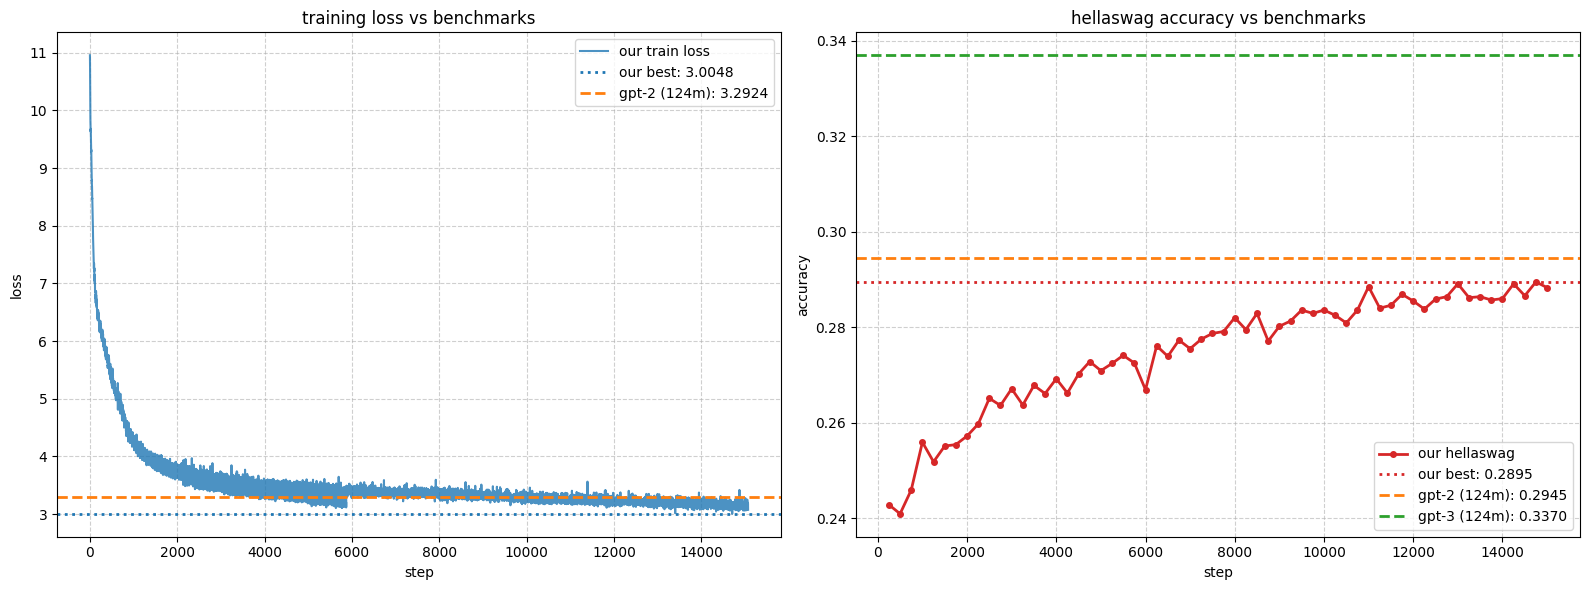

In [23]:
plot_metrics('pretrain', pretraining_log)

### Pretrained Model Inference

In [21]:
pretrain_text, p_time, p_tps = generate_text(
    prompt="the core philosophy of language models is",
    model_path=pretrained_model,
    max_new_tokens=128,
    temperature=0.8,
    top_k=50,
    repetition_penalty=1.0,
    stop_on_eot=False,
    device="cuda"
)

print(f"{p_time} s | {p_tps} tok/sec")
print(pretrain_text)

1.179214600000705 s | 108.54682430146596 tok/sec
that language is a collection of language-like structures and the language is not an expression of it, as it is in all other collections.”
The theory of Language.
The language theory was first observed by Friedrich Nietzsche, while the language theory was first observed by Jürgen Habermas. In his book Die Linguistie das Lieferzeit, Friedrich Nietzsche describes how he used the principle of language to show people the reality of the language of their forefathers. He even refers to the “languages of the human race” in the language of the first and second generation, which


## SFT

### Training Loss & Rouge Evaluation

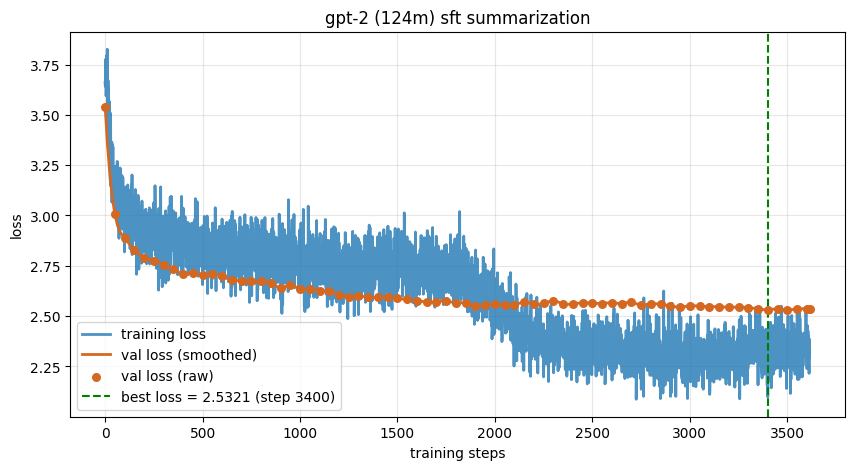

In [24]:
plot_metrics('sft', sft_log)

### Rouge Score Evaluation

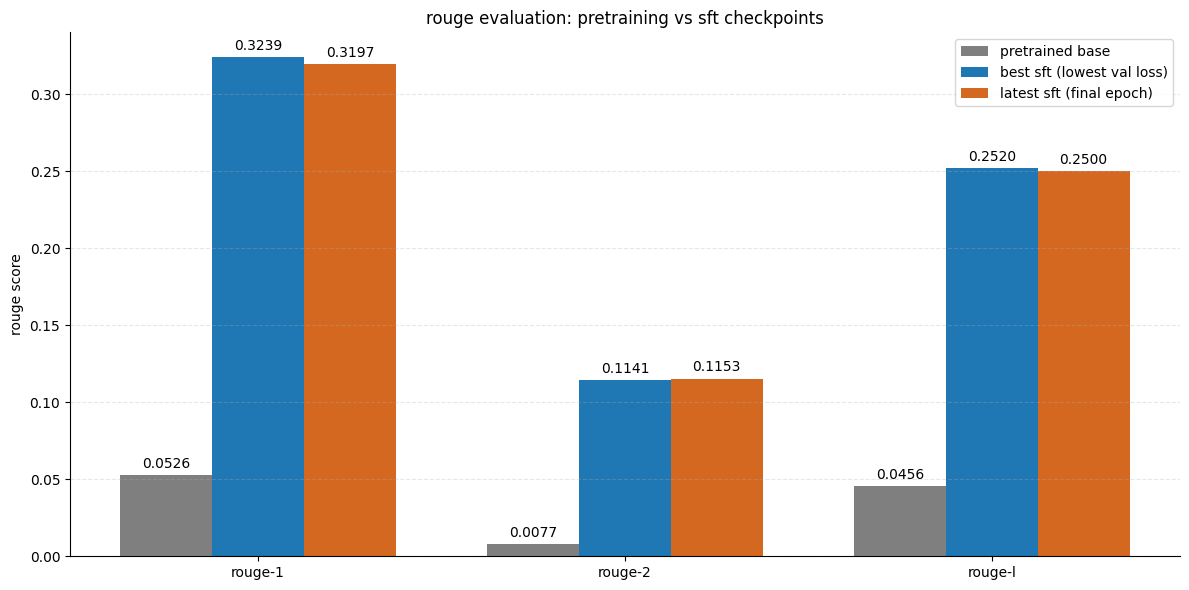

In [27]:
import json

score_file = "log/sft/sft_rouge_scores.json"

if not os.path.exists(score_file):
    print(f"could not find {score_file}. please run evaluation/eval_rouge.py first.")
else:
    with open(score_file, "r") as f:
        results = json.load(f)

    metrics = ['rouge-1', 'rouge-2', 'rouge-l']
    
    pretrain_dict = results.get("pretrained_model", {"rouge-1": 0, "rouge-2": 0, "rouge-l": 0})
    best_scores_dict = results.get("best_model", {"rouge-1": 0, "rouge-2": 0, "rouge-l": 0})
    latest_scores_dict = results.get("latest_model", {"rouge-1": 0, "rouge-2": 0, "rouge-l": 0})
    
    pretrain_scores = [pretrain_dict[m] for m in metrics]
    best_model_scores = [best_scores_dict[m] for m in metrics]
    latest_model_scores = [latest_scores_dict[m] for m in metrics]

    x = np.arange(len(metrics)) 
    width = 0.25 

    fig, ax = plt.subplots(figsize=(12, 6))

    rects1 = ax.bar(x - width, pretrain_scores, width, label='pretrained base', color='#7f7f7f')
    rects2 = ax.bar(x, best_model_scores, width, label='best sft (lowest val loss)', color='#1f77b4')
    rects3 = ax.bar(x + width, latest_model_scores, width, label='latest sft (final epoch)', color='#d46821')

    ax.set_ylabel('rouge score')
    ax.set_title('rouge evaluation: pretraining vs sft checkpoints')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    ax.bar_label(rects1, padding=3, fmt='%.4f')
    ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.bar_label(rects3, padding=3, fmt='%.4f')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    fig.tight_layout()
    plt.show()

### SFT Model Inference

#### Best SFT Model

In [13]:
best_sft_text, best_s_time, best_s_tps = generate_text(
    prompt="post: i lost my keys and got locked out.\n\ntl;dr:",
    model_path=best_sft_model,
    max_new_tokens=64,
    temperature=0.7,
    top_k=40,
    repetition_penalty=1.0,
    stop_on_eot=True,
    device="cuda"
)

print(f"{best_s_time} s | {best_s_tps} tok/sec")
print(best_sft_text)

0.2878807000015513 s | 93.78885072828608 tok/sec
post: i lost my keys and got locked out.

tl;dr: I have a really stupid problem with my keys and it will probably end up being a huge problem if I have to have them.


#### Final SFT Model

In [15]:
final_sft_text, final_s_time, final_s_tps = generate_text(
    prompt="post: i lost my keys and got locked out.\n\ntl;dr:",
    model_path=final_sft_model,
    max_new_tokens=64,
    temperature=0.7,
    top_k=40,
    repetition_penalty=1.0,
    stop_on_eot=True,
    device="cuda"
)

print(f"{final_s_time} s | {final_s_tps} tok/sec")
print(final_sft_text)

0.6716722999990452 s | 95.2845606407931 tok/sec
post: i lost my keys and got locked out.

tl;dr: The only way to get rid of keys is to clean them up. Just clean them up. Just clean them up. Just clean them up. Just clean them up. Just clean them up. Just clean them up. Just clean them up. Just clean them up. Just clean them up. Just clean them up.


## Reward Model

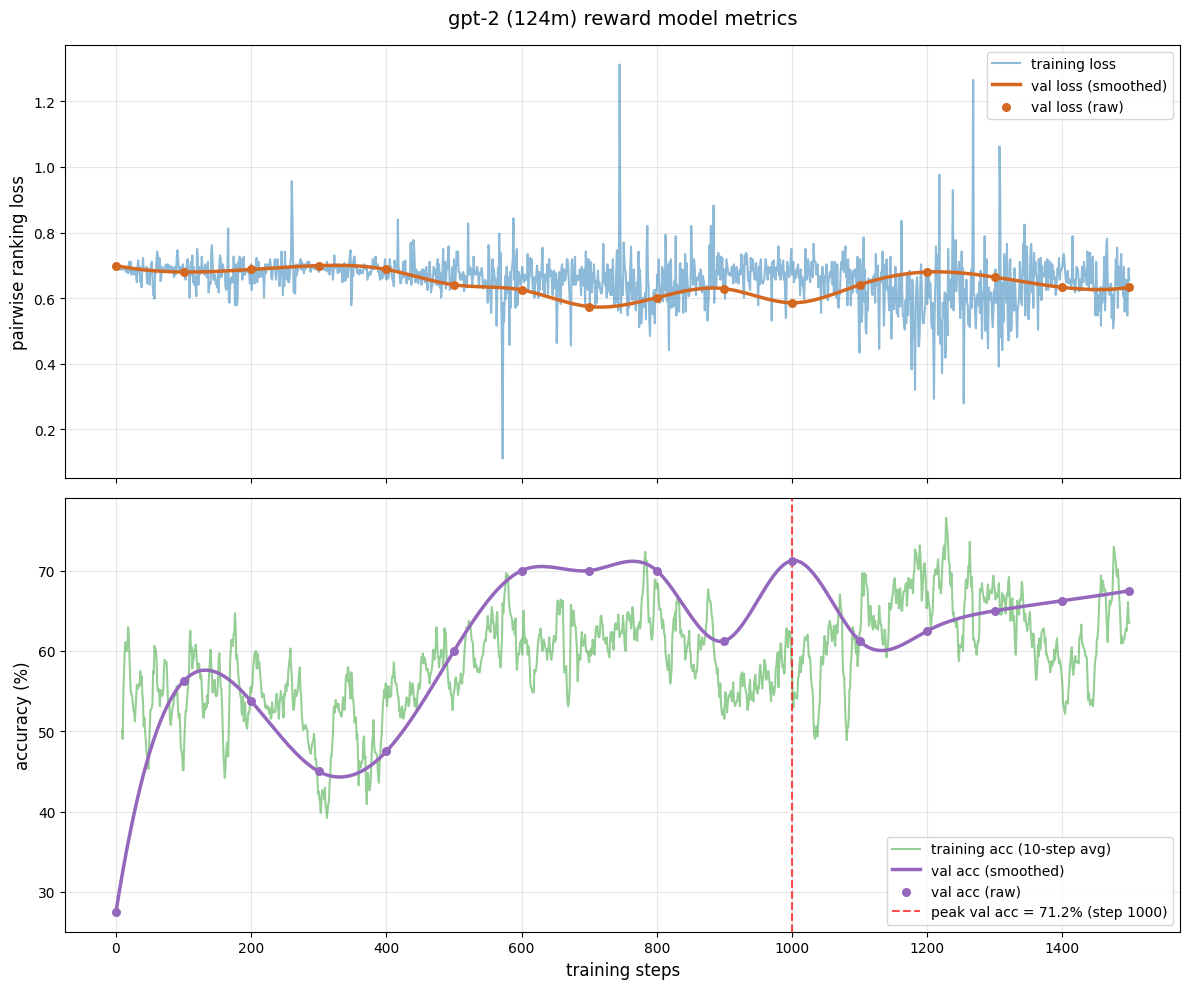

In [25]:
plot_metrics('rm', rm_log)

## PPO Model

### Loss & Reward

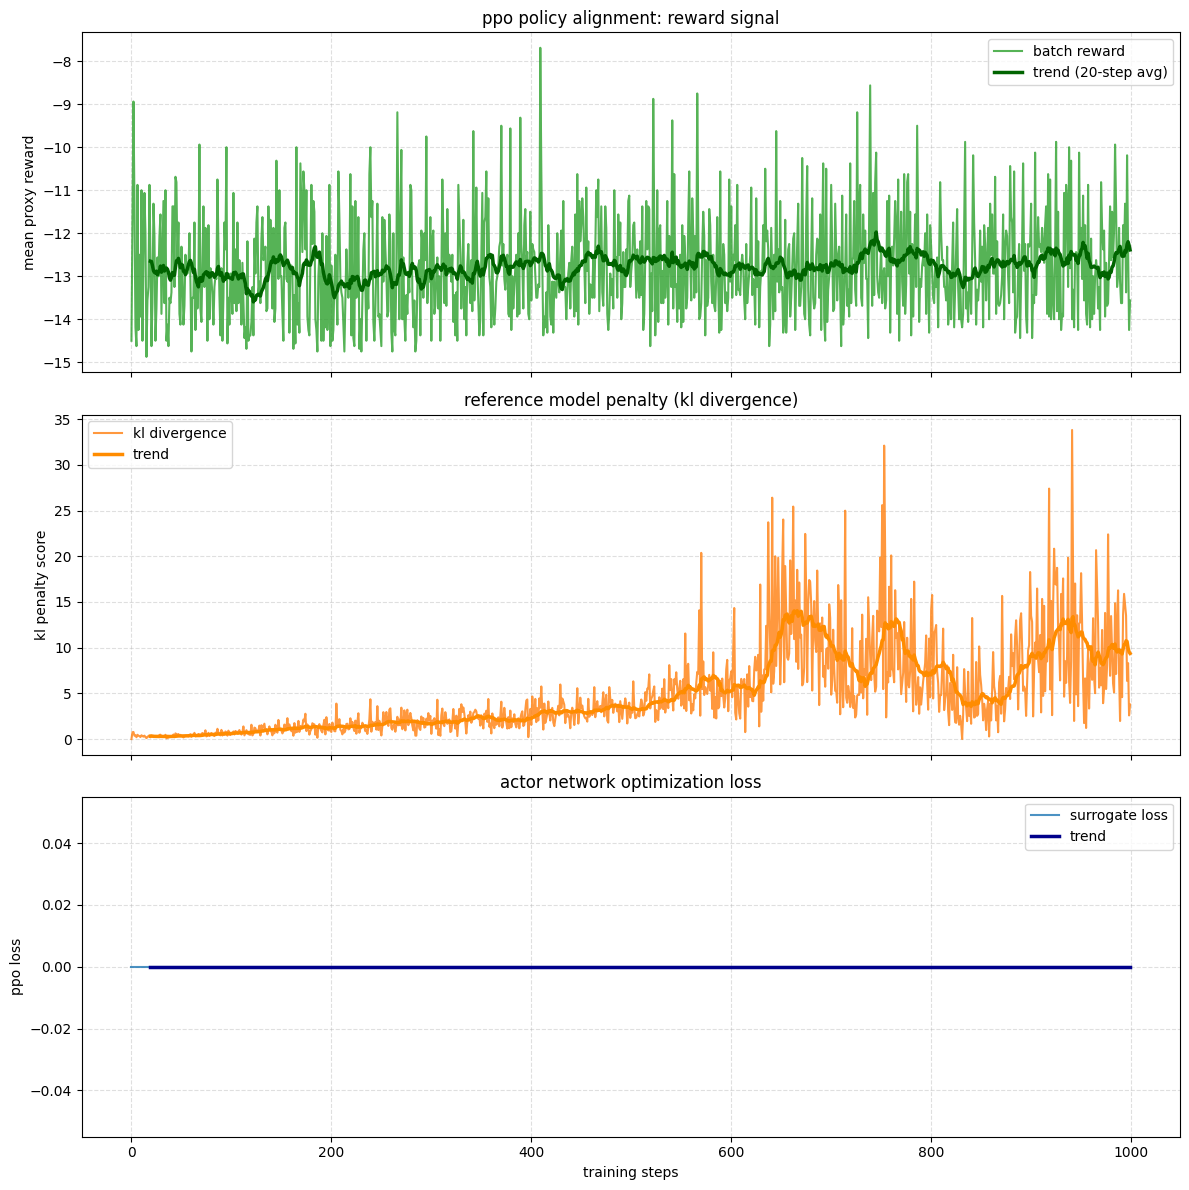

In [26]:
plot_metrics('ppo', ppo_log)

### Inference

In [20]:
preset_prompts = [
    "I have a roommate who keeps eating my food without asking. Every single time I buy groceries, half of it disappears within 48 hours. I tried talking to him politely but he just laughs it off and says he will replace it, but he never does. Should I get a mini-fridge for my room or confront him one last time more aggressively?",
    "My boss asked me to work over the weekend for a major client launch, but it is completely short notice and I already booked non-refundable tickets to visit my parents. If I say no, I am worried it will impact my performance review next month, but if I go, I disappoint my family. How do I navigate this professionally?",
    "I am trying to decide whether to buy a new laptop for college or stick with my desktop setup. The laptop would let me work from the library and study groups, but my desktop is vastly more powerful and already paid for. My budget is tight and I would have to take out a small student loan to afford the laptop.",
    "Yesterday I went to a local coffee shop and paid for a $5 latte with a $20 bill. The cashier accidentally gave me change for a $50 bill instead. I realized the mistake only after I walked back to my car. Part of me wants to go back and return the extra cash, but another part feels like it was their operational error.",
    "Our landlord just announced a 15% rent increase starting next month, citing market adjustments. The apartment has several maintenance issues that have been completely ignored for six months, like a leaking kitchen pipe and a broken window latch. Is it worth fighting this legally or should I look for a new place?"
]

for raw_prompt in preset_prompts:
    formatted_prompt = f"Post: {raw_prompt}\n\nTL;DR: "
    
    ppo_text, ppo_time, ppo_tps = generate_text(
        prompt=formatted_prompt,
        model_path=ppo_model,
        max_new_tokens=128,
        temperature=0.5,
        top_k=40,
        repetition_penalty=1.3,
        stop_on_eot=True,
        device="cuda"
    )
    
    print(f"post: {raw_prompt}")
    print(f"summary: {ppo_text}")
    print(f"metrics: {ppo_time:.3f} s | {ppo_tps:.2f} tok/sec")
    print('-'*60)

post: I have a roommate who keeps eating my food without asking. Every single time I buy groceries, half of it disappears within 48 hours. I tried talking to him politely but he just laughs it off and says he will replace it, but he never does. Should I get a mini-fridge for my room or confront him one last time more aggressively?
summary: I have a roommate who keeps eating my groceries without asking, and I don't want him to do it again. Should I confront him?
metrics: 0.513 s | 56.51 tok/sec
------------------------------------------------------------
post: My boss asked me to work over the weekend for a major client launch, but it is completely short notice and I already booked non-refundable tickets to visit my parents. If I say no, I am worried it will impact my performance review next month, but if I go, I disappoint my family. How do I navigate this professionally?
summary: My boss asked me to work over the weekend for a major client launch, but I already booked non-refundable t